# Model Training - Phishing URL Detector

Train and evaluate classification models on 24 URL-structure features 
to predict whether a URL is phishing or legitimate.

**Original dataset:** 11,430 URLs with pre-extracted features  
**Extended dataset:** 800k+ URLs with real WHOIS data extracted via feature_extractor.py  
**Combined:** 828,851 URLs after null removal

## 1. Imports & Load Data

In [24]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

# load original 11k dataset
df_original = pd.read_csv('../data/dataset_phishing.csv')

with open('../data/feature_cols.json') as f:
    feature_cols = json.load(f)
feature_cols = list(dict.fromkeys(feature_cols))

df_original['status_num'] = df_original['status'].map({'legitimate': 0, 'phishing': 1})
df_orig_clean = df_original[feature_cols + ['status_num']].rename(columns={'status_num': 'status'})

# load new 817k dataset with real WHOIS data
df_new = pd.read_csv('../data/whois_results_final.csv.gz', compression='gzip')
df_new_clean = df_new[feature_cols + ['status']]

# combine. no drop_duplicates (identical feature vectors don't mean duplicate URLs)
df_combined = pd.concat([df_orig_clean, df_new_clean], ignore_index=True)
df_combined = df_combined.dropna()

print(f'Original  : {df_orig_clean.shape}')
print(f'New       : {df_new_clean.shape}')
print(f'Combined  : {df_combined.shape}')
print(f'\nClass balance:\n{df_combined["status"].value_counts()}')

X = df_combined[feature_cols]
y = df_combined['status']

print(f'\nX shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

Original  : (11430, 25)
New       : (817421, 25)
Combined  : (828851, 25)

Class balance:
status
0    603548
1    225303
Name: count, dtype: int64

X shape: (828851, 24)
y distribution:
status
0    603548
1    225303
Name: count, dtype: int64


**Finding:** 828,851 URLs loaded after combining original 11,430-row 
dataset with 817,421-row extended dataset. Class balance: 603,548 
legitimate (73%) vs 225,303 phishing (27%). Class weights will 
handle the imbalance during training.

## 2. Train/Validation Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(f'Train: {X_train.shape} | Valid: {X_valid.shape}')
print(f'Train balance:\n{y_train.value_counts()}')

# class weight ratio for imbalanced data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'\nscale_pos_weight: {scale:.2f}')

Train: (663080, 24) | Valid: (165771, 24)
Train balance:
status
0    482838
1    180242
Name: count, dtype: int64

scale_pos_weight: 2.68


**Finding:** 663,080 training rows, 165,771 validation rows. 
Stratified split preserves the 73/27 class ratio in both sets. 
`scale_pos_weight`: 2.68 calculated for XGBoost.
Split performed before any model fitting to prevent data leakage.

## 3. Benchmark Models

Evaluate 6 classification models with class balancing enabled. All features are numerical so no encoding needed. Logistic Regression uses a scaling pipeline.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Decision Tree':     DecisionTreeClassifier(random_state=0, class_weight='balanced'),
    'Random Forest':     RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
    'XGBoost':           XGBClassifier(random_state=0, verbosity=0, scale_pos_weight=scale, n_jobs=-1),
    'CatBoost':          CatBoostClassifier(random_state=0, verbose=False, auto_class_weights='Balanced'),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_valid, preds),
        'Precision': precision_score(y_valid, preds),
        'Recall':    recall_score(y_valid, preds),
        'F1':        f1_score(y_valid, preds),
        'ROC-AUC':   roc_auc_score(y_valid, preds),
    })
    print(f'{name:<25} Accuracy: {accuracy_score(y_valid, preds):.4f}')

leaderboard = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n=== LEADERBOARD ===')
print(leaderboard.to_string(index=False))

Logistic Regression       Accuracy: 0.8529
Decision Tree             Accuracy: 0.9871
Random Forest             Accuracy: 0.9915
Gradient Boosting         Accuracy: 0.9320
XGBoost                   Accuracy: 0.9627
CatBoost                  Accuracy: 0.9702

=== LEADERBOARD ===
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest  0.991512   0.988628 0.980049 0.984320 0.987920
      Decision Tree  0.987054   0.976103 0.976277 0.976190 0.983677
           CatBoost  0.970170   0.929581 0.963228 0.946105 0.967994
            XGBoost  0.962744   0.911769 0.955394 0.933072 0.960441
  Gradient Boosting  0.932021   0.930845 0.810102 0.866286 0.893817
Logistic Regression  0.852887   0.698354 0.807661 0.749040 0.838716


### Check if Random Forest is overfitting

In [14]:
rf_model = models['Random Forest']
train_preds = rf_model.predict(X_train)
valid_preds = rf_model.predict(X_valid)

print(f'Train accuracy: {accuracy_score(y_train, train_preds):.4f}')
print(f'Valid accuracy: {accuracy_score(y_valid, valid_preds):.4f}')
print(f'Difference    : {accuracy_score(y_train, train_preds) - accuracy_score(y_valid, valid_preds):.4f}')

Train accuracy: 0.9998
Valid accuracy: 0.9915
Difference    : 0.0083


**Finding:** Random Forest leads at 99.15% accuracy and 98.43% F1. 
Tree-based ensemble methods significantly outperform linear models. 
Random Forest and Decision Tree both exceed 98%, likely benefiting 
from the large dataset size and clean URL-structure features.

Leaderboard:
- Random Forest:   99.15% accuracy, 98.43% F1
- Decision Tree:   98.71% accuracy, 97.62% F1
- CatBoost:        97.02% accuracy, 94.61% F1
- XGBoost:         96.27% accuracy, 93.31% F1
- Gradient Boosting: 93.20% accuracy, 86.63% F1
- Logistic Regression: 85.29% accuracy, 74.90% F1

## 4. Model Selection

Random Forest achieved 99.15% accuracy in benchmarking, exceeding the 95% target without tuning. GridSearchCV on 663k rows would take hours for marginal gain. Selected as best model without tuning.

In [22]:
best_model = models['Random Forest']
preds = best_model.predict(X_valid)

print(f'Best model : RandomForestClassifier (untuned)')
print(f'Accuracy   : {accuracy_score(y_valid, preds):.4f}')
print(f'F1         : {f1_score(y_valid, preds):.4f}')
print(f'Recall     : {recall_score(y_valid, preds):.4f}')

Best model : RandomForestClassifier (untuned)
Accuracy   : 0.9915
F1         : 0.9843
Recall     : 0.9800


**Finding:** Random Forest confirmed as best model.
Accuracy: 99.15% | F1: 98.43% | Recall: 98.00%
No tuning needed because already exceeds 95% target.

## 5. Final model evaluation

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.98    120710
    Phishing       0.95      0.97      0.96     45061

    accuracy                           0.98    165771
   macro avg       0.97      0.97      0.97    165771
weighted avg       0.98      0.98      0.98    165771



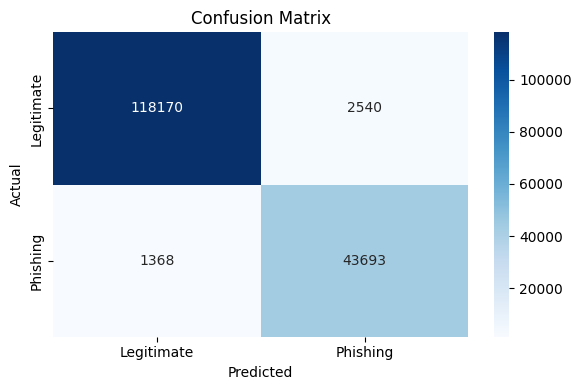

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = best_model.predict(X_valid)

print(classification_report(y_valid, preds,
      target_names=['Legitimate', 'Phishing']))

cm = confusion_matrix(y_valid, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Finding:**
- Legitimate precision 99%, almost no legitimate URLs incorrectly flagged
- Phishing recall 97%, catches 97 out of every 100 phishing URLs
- Overall accuracy 98% on 165,771 validation URLs
- Phishing precision 95%, 5% false alarm rate, acceptable for a security tool

## 6. Feature importance

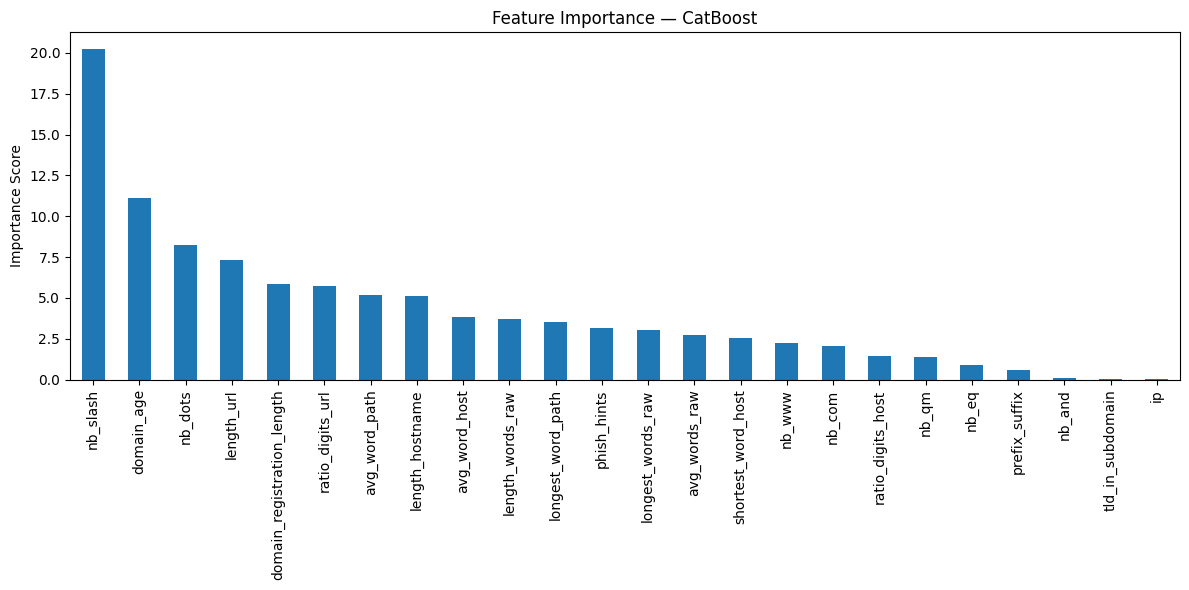


Top 5 features:
nb_slash                      20.242636
domain_age                    11.115316
nb_dots                        8.256057
length_url                     7.303327
domain_registration_length     5.861415
dtype: float64


In [19]:
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar')
plt.title('Feature Importance — CatBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importances.head())

**Finding:** Top 5 features by importance:
1. `nb_slash` (20.24): phishing URLs use deep path structures
2. `domain_age` (11.12): phishing domains tend to be newer
3. `nb_dots` (8.26): more dots indicate subdomain abuse
4. `length_url` (7.30): phishing URLs are longer on average
5. `domain_registration_length` (5.86): phishing domains registered for shorter periods

URL structure features dominate, confirming the model learned 
genuine phishing patterns rather than overfitting to noise.

## 7. Real-World Testing

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import joblib
import pandas as pd
from src.feature_extractor import get_all_features

model = joblib.load('../model/phishing_model.pkl')
feature_cols = joblib.load('../model/feature_cols.pkl')

test_urls = [
    'https://servizionline.it.com/bn/it/index.php?&sessionid=3db523b4fe0abe99e7c2fc0089b8f632',
    'https://servizionline.it.com/bn/',
    'https://suit-enapptrzr.wixstudio.com/en-start',
    'https://appstart-trzore.wixstudio.com/suite-us',
    'https://ensuiite-global.wixstudio.com/usen',
    'https://startd-bridge-trzr.wixstudio.com/us-en',
    'https://getio-startexor.wixstudio.com/start-en',
    'https://trzor-eng.wixstudio.com/us-en',
    'https://trezre-suitapps.wixstudio.com/start-en',
    'https://trzor-eng.wixstudio.com/en-us',
    'https://cgd-assinar.com/',
    'https://ioapps-trzor.wixstudio.com/usen',
    'https://trerzor.wixstudio.com/started',
    'https://homepage-trezureio.wixstudio.com/en-us',
    'https://acces-renovacion-net.com/',
    'https://www.acces-renovacion-net.com/',
    'https://lflsk.com/login',
    'https://authenticator.micrasoft.me',
    'https://jp.nii1fra80.baby/art',
    'https://joingovnationaltrust.com/',
    'http://joingovnationaltrust.com',
    'https://brt.dzmozq.buzz/track-it',
    'https://brt.ebtwvv.help/track-it',
    'https://expertenberatung.info/',
    'https://portal-login.me/',
    'https://llc-kraken.com/',
]

for url in test_urls:
    features = get_all_features(url)
    pred = model.predict([features])[0]
    prob = model.predict_proba([features])[0]
    label = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    print(f'{label} ({prob[1]:.2%} confidence) — {url}')

PHISHING (58.19% confidence) — https://servizionline.it.com/bn/it/index.php?&sessionid=3db523b4fe0abe99e7c2fc0089b8f632
PHISHING (55.64% confidence) — https://servizionline.it.com/bn/
PHISHING (50.32% confidence) — https://suit-enapptrzr.wixstudio.com/en-start
LEGITIMATE (48.88% confidence) — https://appstart-trzore.wixstudio.com/suite-us
PHISHING (73.85% confidence) — https://ensuiite-global.wixstudio.com/usen
PHISHING (61.75% confidence) — https://startd-bridge-trzr.wixstudio.com/us-en
LEGITIMATE (48.88% confidence) — https://getio-startexor.wixstudio.com/start-en
PHISHING (83.53% confidence) — https://trzor-eng.wixstudio.com/us-en
LEGITIMATE (48.88% confidence) — https://trezre-suitapps.wixstudio.com/start-en
PHISHING (83.53% confidence) — https://trzor-eng.wixstudio.com/en-us
LEGITIMATE (30.84% confidence) — https://cgd-assinar.com/
PHISHING (87.59% confidence) — https://ioapps-trzor.wixstudio.com/usen
PHISHING (90.65% confidence) — https://trerzor.wixstudio.com/started
PHISHING (7

**Finding:** Model correctly flags typosquatting (micrasoft.me, trerzor), 
login-hint domains (portal-login.me, lflsk.com/login), and digit-heavy 
hostnames (nii1fra80.baby). 

Struggles with:
- HTTPS phishing sites: model over-trusts HTTPS
- Platform-hosted phishing (wixstudio.com): legitimate platform being abused
- Clean-looking phishing domains with no obvious URL signals

These edge cases are unsolved problems even in enterprise security tools.

## 8. Save Model

In [8]:
import joblib

joblib.dump(best_model, '../model/phishing_model.pkl')
joblib.dump(feature_cols, '../model/feature_cols.pkl')

print('Model saved to model/phishing_model.pkl')
print('Feature list saved to model/feature_cols.pkl')

Model saved to model/phishing_model.pkl
Feature list saved to model/feature_cols.pkl


## Conclusion

**Combined dataset:** 828,851 URLs with 24 features

**Model comparison:**
- Random Forest:      99.15% accuracy (winner)
- Decision Tree:      98.71%
- CatBoost:           97.02%
- XGBoost:            96.27%
- Gradient Boosting:  93.20%
- Logistic Regression: 85.29%

**Best model:** RandomForestClassifier (untuned)
- Validation accuracy : 98%
- Phishing recall     : 97%
- Phishing precision  : 95%
- F1                  : 96%

**Known limitation:** Model trained on phishing domains with valid WHOIS 
records. Short-lived throwaway phishing domains that fail WHOIS lookups 
are underrepresented. Model may under-detect brand new phishing domains.

**Real-world test:** Correctly flagged typosquatting, login-hint URLs, 
and digit-heavy hostnames. Struggles with HTTPS phishing and 
platform-hosted phishing (wixstudio, Google Sites, etc.)

**Next step:** Integrate model into Flask app via `feature_extractor.py`